In [19]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import ImageEncoding
from ImageModelUtils import OrderFlowRegressor
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import importlib
importlib.reload(ImageEncoding)

<module 'ImageEncoding' from '/content/ImageEncoding.py'>

In [21]:
stocks_to_plot = [28, 66, 98]
DATA_DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction'
LOCAL_DATA_DIR = '/content'
MODEL_PATH = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/'
data = {
    "book_train": {},
    "trade_train": {}
}
for stock_id in stocks_to_plot:
    book_train = pd.read_parquet(f"{DATA_DIR}/book_train.parquet/stock_id={stock_id}")
    trade_train = pd.read_parquet(f"{DATA_DIR}/trade_train.parquet/stock_id={stock_id}")
    book_train['stock_id'] = stock_id
    trade_train['stock_id'] = stock_id
    data["book_train"][stock_id] = book_train
    data["trade_train"][stock_id] = trade_train
pd.concat([data["book_train"][stock_id] for stock_id in stocks_to_plot], ignore_index=True).to_parquet(f"{LOCAL_DATA_DIR}/book_train.parquet")
pd.concat([data["trade_train"][stock_id] for stock_id in stocks_to_plot], ignore_index=True).to_parquet(f"{LOCAL_DATA_DIR}/trade_train.parquet")
train = pd.read_csv(f"{DATA_DIR}/train.csv")
train=train[train["stock_id"].isin(stocks_to_plot)]
train.to_csv(f"{LOCAL_DATA_DIR}/train.csv", index=False)

In [22]:
def criterion(pred, target):
    return ((pred - target)/target)**2
device = "cuda"
img_transform = ImageEncoding.ToImage(output_size=(600, 160, 3))
dataset = ImageEncoding.OrderFlowDataset(
    f"{LOCAL_DATA_DIR}/train.csv", 
    f"{LOCAL_DATA_DIR}/book_train.parquet", 
    f"{LOCAL_DATA_DIR}/trade_train.parquet", 
    transform=img_transform
)

dataloader = DataLoader(dataset, batch_size = 128)
model = OrderFlowRegressor().to(device)
model.load_state_dict(torch.load(f"{MODEL_PATH}/best_model.pth", weights_only = True))
model.eval()

OrderFlowRegressor(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
      

In [ ]:
results = {"stock_id":[], "time_id": [], "target":[], "model": [], "loss": []}
for batch in dataloader:
    # print(batch)
    stock_ids = batch["stock_id"]

    mask = torch.isin(stock_ids, torch.tensor(stocks_to_plot))
    if not mask.any():
        continue
    images = batch["image"][mask]
    images = images.permute(0, 3, 1, 2)
    images = images.to(device, dtype = torch.float32)

    with torch.no_grad():
        preds = model(images).cpu()
        loss = criterion(preds, batch["r_vol"][mask])
        
    time_ids = batch["time_id"]
    results["stock_id"].extend(stock_ids.tolist())
    results["time_id"].extend(time_ids.tolist())
    results["target"].extend(preds.tolist())
    results["loss"].extend(loss.tolist())


{'image': tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         ...,

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


       

ValueError: All arrays must be of the same length

In [31]:
preds_df = pd.DataFrame(results)

In [33]:
preds_df.sort_values(by=["stock_id", "time_id"], inplace=True)

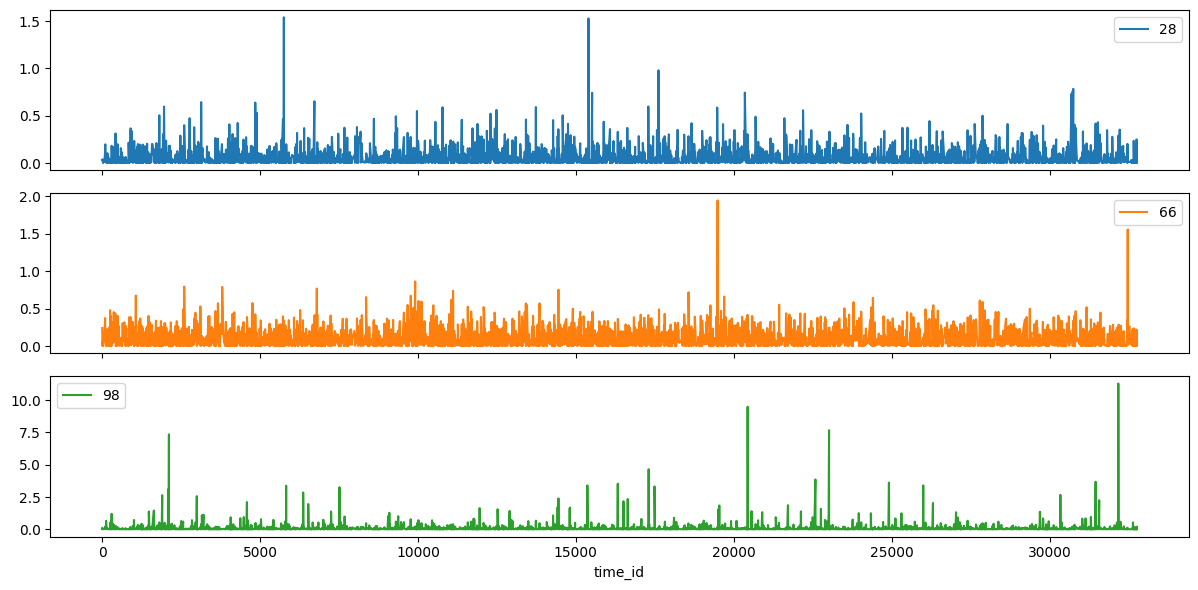

In [ ]:
import matplotlib.pyplot as plt
axes = preds_df.pivot(index='time_id', columns='stock_id', values='loss').plot(
    subplots=True, 
    figsize=(14, 8), 
    title="Loss vs. Time ID per Stock"
)

for ax in axes:
    ax.set_ylabel("Loss")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()